# EDA -- Exploratory Data Analysis 


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

In [3]:
# ── Constants ────────────────────────────────────────────────────────────────
ROOT_DIR  = Path.cwd()
DATA_DIR  = ROOT_DIR / "data"
PLOTS_DIR = ROOT_DIR / "plots" / "eda_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PALETTE = "husl"

# Cargar data

In [4]:

# ── Load data ─────────────────────────────────────────────────────────────────
transacciones = pd.read_csv(DATA_DIR / "customer_purchases_train.csv")
print(f"  transacciones: {transacciones.shape}")
print(transacciones.head())

  transacciones: (6892, 18)
   purchase_id customer_id customer_date_of_birth customer_gender  \
0            0   CUST_0094             03/05/1996          female   
1            1   CUST_0279             05/02/1974          female   
2            2   CUST_0775             09/10/1954            male   
3            3   CUST_0722             05/07/1963            male   
4            4   CUST_0741             07/08/1957          female   

  customer_signup_date    item_id                           item_title  \
0           07/02/2025  ITEM_0101  Exclusive Premium Blouse Collection   
1           03/02/2025  ITEM_0311         Casual Jeans That Stands Out   
2           01/02/2025  ITEM_0752    Stylish Blouse For Every Occasion   
3           13/02/2025  ITEM_0698               Modern Shoes Must Have   
4           22/01/2025  ITEM_0698               Modern Shoes Must Have   

  item_category  item_price item_img_filename  item_avg_rating  \
0        blouse     1310.13     ITEM_0101.png 

# Valores faltantes

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(20, 6))
axes = [axes]

fig.suptitle("Missing Values (% of rows)", fontsize=14, fontweight="bold")

for ax, (label, df) in zip(axes, [
    ("transacciones", transacciones),
]):
    miss = (df.isnull().mean() * 100).sort_values(ascending=True)

    miss = miss[miss > 0]

    if miss.empty:
        ax.text(0.5, 0.5, "No nulls", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.set_title(label)
    else:
        miss.plot(kind="barh", ax=ax,
                  color=sns.color_palette(PALETTE, len(miss)))

        ax.set_title(label)
        ax.set_xlabel("% missing")

        for bar, val in zip(ax.patches, miss):
            ax.text(bar.get_width() + 0.5,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%",
                    va="center",
                    fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_missing_data_overview.png",
            dpi=150,
            bbox_inches="tight")
plt.close()

## 1. Análisis general con libreria Y-data profilling

In [6]:
import pandas as pd
from ydata_profiling import ProfileReport

# Generate the profile report
profile = ProfileReport(transacciones, title="Dataset Profiling Report", explorative=True)

# Save as an HTML file
profile.to_file("output_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:01<00:00, 14.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 2 · Análisis Orientado al Negocio


### Columnas derivadas

In [6]:
# ── Fecha de referencia del snapshot ─────────────────────────────────────────
SNAPSHOT_DATE = pd.Timestamp("2026-05-14")
DATE_FMT      = "%d/%m/%Y"

df = transacciones.copy()

# Parsear fechas
date_cols = [
    "customer_date_of_birth",
    "customer_signup_date",
    "item_release_date",
    "purchase_timestamp",
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format=DATE_FMT, errors="coerce")

# Columnas derivadas clave
df["customer_age"]          = (SNAPSHOT_DATE - df["customer_date_of_birth"]).dt.days // 365
df["customer_tenure_days"]  = (SNAPSHOT_DATE - df["customer_signup_date"]).dt.days
df["days_since_release"]    = (df["purchase_timestamp"] - df["item_release_date"]).dt.days
df["days_since_purchase"]   = (SNAPSHOT_DATE - df["purchase_timestamp"]).dt.days
df["purchase_month"]        = df["purchase_timestamp"].dt.to_period("M").astype(str)
df["purchase_dow"]          = df["purchase_timestamp"].dt.day_name()

print(df[["customer_age", "customer_tenure_days",
          "days_since_release", "days_since_purchase"]].describe().round(1))

       customer_age  customer_tenure_days  days_since_release  \
count        6892.0                6892.0              6892.0   
mean           45.7                 227.2                55.9   
std            16.3                 130.1                76.7   
min            18.0                   4.0                 0.0   
25%            27.0                 130.0                 8.0   
50%            49.0                 205.0                25.0   
75%            59.0                 308.0                69.0   
max            75.0                 688.0               704.0   

       days_since_purchase  
count               6892.0  
mean                 100.0  
std                   83.4  
min                    1.0  
25%                   33.0  
50%                   73.0  
75%                  149.2  
max                  461.0  


### Compras en el tiempo

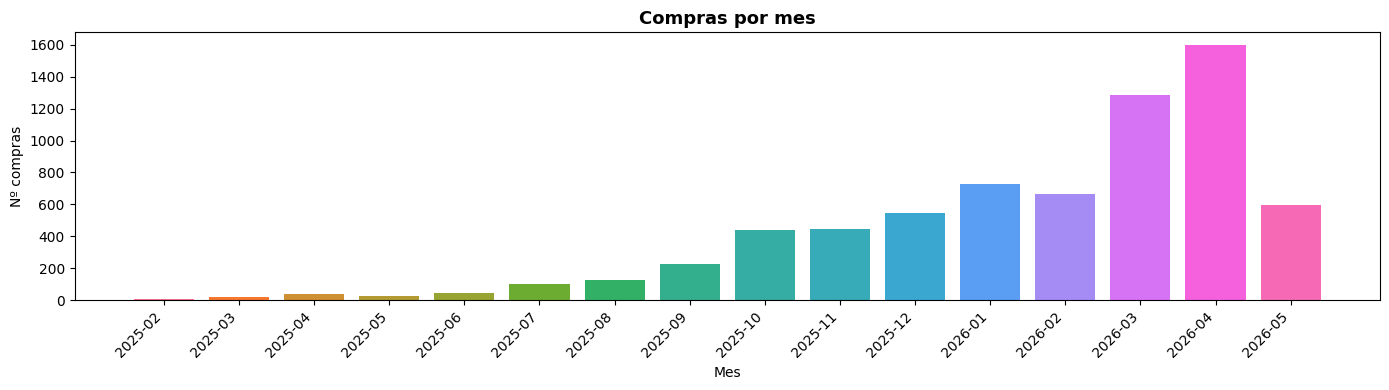

In [7]:
monthly = df.groupby("purchase_month").size().reset_index(name="n_purchases")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly["purchase_month"], monthly["n_purchases"],
       color=sns.color_palette(PALETTE, len(monthly)))
ax.set_title("Compras por mes", fontsize=13, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Nº compras")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_compras_por_mes.png", dpi=150, bbox_inches="tight")
plt.show()

### Perfil de cliente

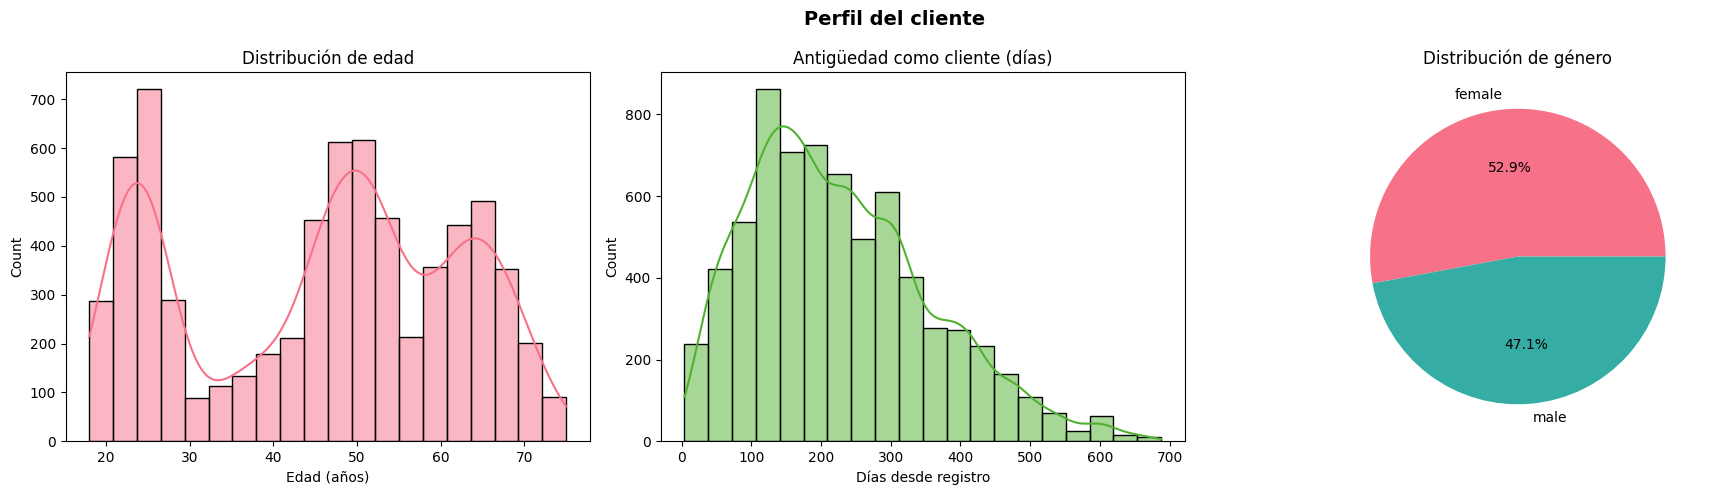

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Perfil del cliente", fontsize=14, fontweight="bold")

# Edad
sns.histplot(df["customer_age"].dropna(), bins=20, kde=True,
             ax=axes[0], color=sns.color_palette(PALETTE)[0])
axes[0].set_title("Distribución de edad")
axes[0].set_xlabel("Edad (años)")

# Antigüedad como cliente
sns.histplot(df["customer_tenure_days"].dropna(), bins=20, kde=True,
             ax=axes[1], color=sns.color_palette(PALETTE)[2])
axes[1].set_title("Antigüedad como cliente (días)")
axes[1].set_xlabel("Días desde registro")

# Género
gender_counts = df["customer_gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette(PALETTE, len(gender_counts)))
axes[2].set_title("Distribución de género")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_perfil_cliente.png", dpi=150, bbox_inches="tight")
plt.show()

### Analizamos catalogo de productos

C:\Users\Hp\AppData\Local\Temp\ipykernel_7852\4254387115.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="item_category", y="item_price",


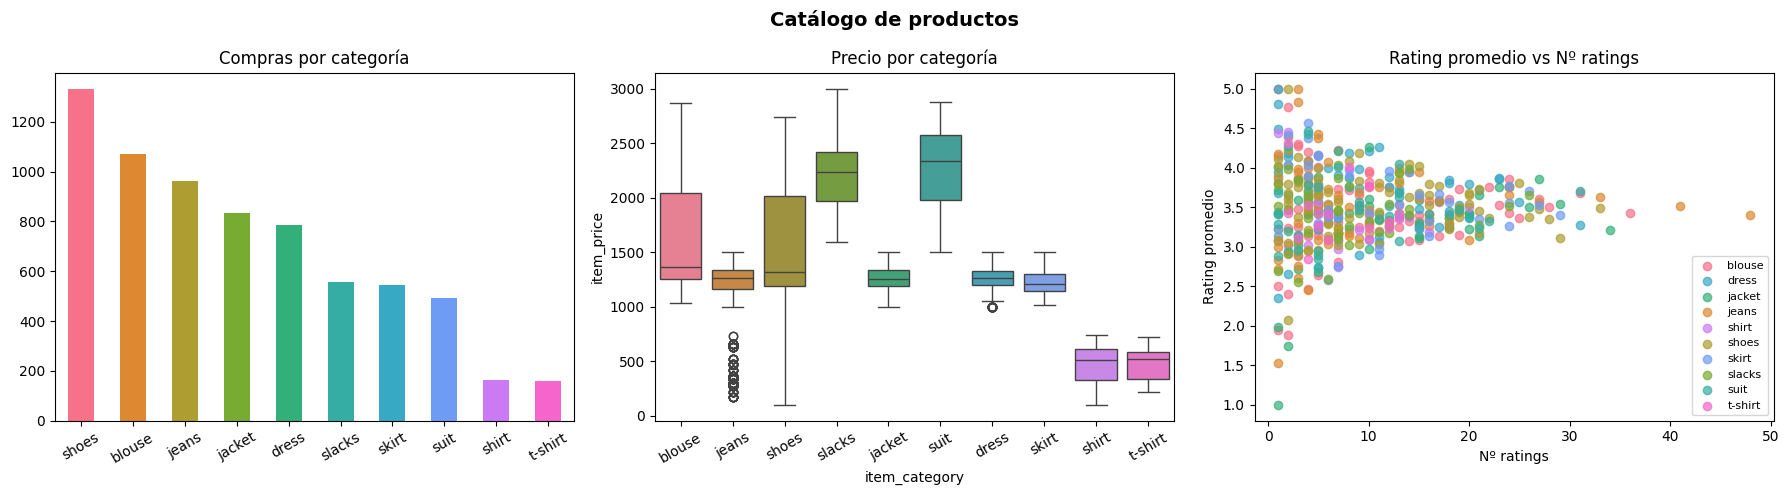

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Catálogo de productos", fontsize=14, fontweight="bold")

# Ventas por categoría
cat_counts = df["item_category"].value_counts()
cat_counts.plot(kind="bar", ax=axes[0],
                color=sns.color_palette(PALETTE, len(cat_counts)))
axes[0].set_title("Compras por categoría")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# Distribución de precios por categoría
sns.boxplot(data=df, x="item_category", y="item_price",
            palette=PALETTE, ax=axes[1])
axes[1].set_title("Precio por categoría")
axes[1].tick_params(axis="x", rotation=30)

# Rating promedio del ítem vs nº ratings
item_stats = df.drop_duplicates("item_id")[["item_avg_rating", "item_num_ratings", "item_category"]]
scatter_palette = dict(zip(item_stats["item_category"].unique(),
                           sns.color_palette(PALETTE, item_stats["item_category"].nunique())))
for cat, grp in item_stats.groupby("item_category"):
    axes[2].scatter(grp["item_num_ratings"], grp["item_avg_rating"],
                    label=cat, color=scatter_palette[cat], alpha=0.7)
axes[2].set_title("Rating promedio vs Nº ratings")
axes[2].set_xlabel("Nº ratings")
axes[2].set_ylabel("Rating promedio")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_catalogo_productos.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── Métricas por cliente ──────────────────────────────────────────────────────
rfm = df.groupby("customer_id").agg(
    recency        = ("days_since_purchase", "min"),       # días desde última compra
    frequency      = ("purchase_id",         "count"),    # total de compras
    monetary_mean  = ("item_price",           "mean"),    # ticket promedio
    monetary_sum   = ("item_price",           "sum"),     # gasto total
    avg_views      = ("customer_item_views",  "mean"),    # views promedio
    categories_cnt = ("item_category",        "nunique"), # diversidad de categorías
    has_rating     = ("purchase_item_rating", lambda x: x.notna().mean()),  # % compras con rating
    mobile_ratio   = ("purchase_device",      lambda x: (x == "mobile").mean()),
).reset_index()

print(f"Clientes únicos: {len(rfm):,}")
print(rfm.describe().round(2))

Clientes únicos: 779
       recency  frequency  monetary_mean  monetary_sum  avg_views  \
count   779.00     779.00         779.00        779.00     779.00   
mean     24.93       8.85        1221.33      12926.64       5.49   
std      28.13       5.67         615.65      10735.48       1.10   
min       1.00       1.00         100.00        100.00       1.00   
25%       6.00       4.00         614.42       1892.78       5.00   
50%      15.00       8.00        1245.86      11198.71       5.47   
75%      30.00      13.00        1304.54      20102.48       6.00   
max     194.00      27.00        2540.57      47644.37      13.00   

       categories_cnt  has_rating  mobile_ratio  
count          779.00      779.00        779.00  
mean             2.78        0.20          0.54  
std              0.85        0.18          0.34  
min              1.00        0.00          0.00  
25%              2.00        0.00          0.24  
50%              3.00        0.17          0.56  
75%    

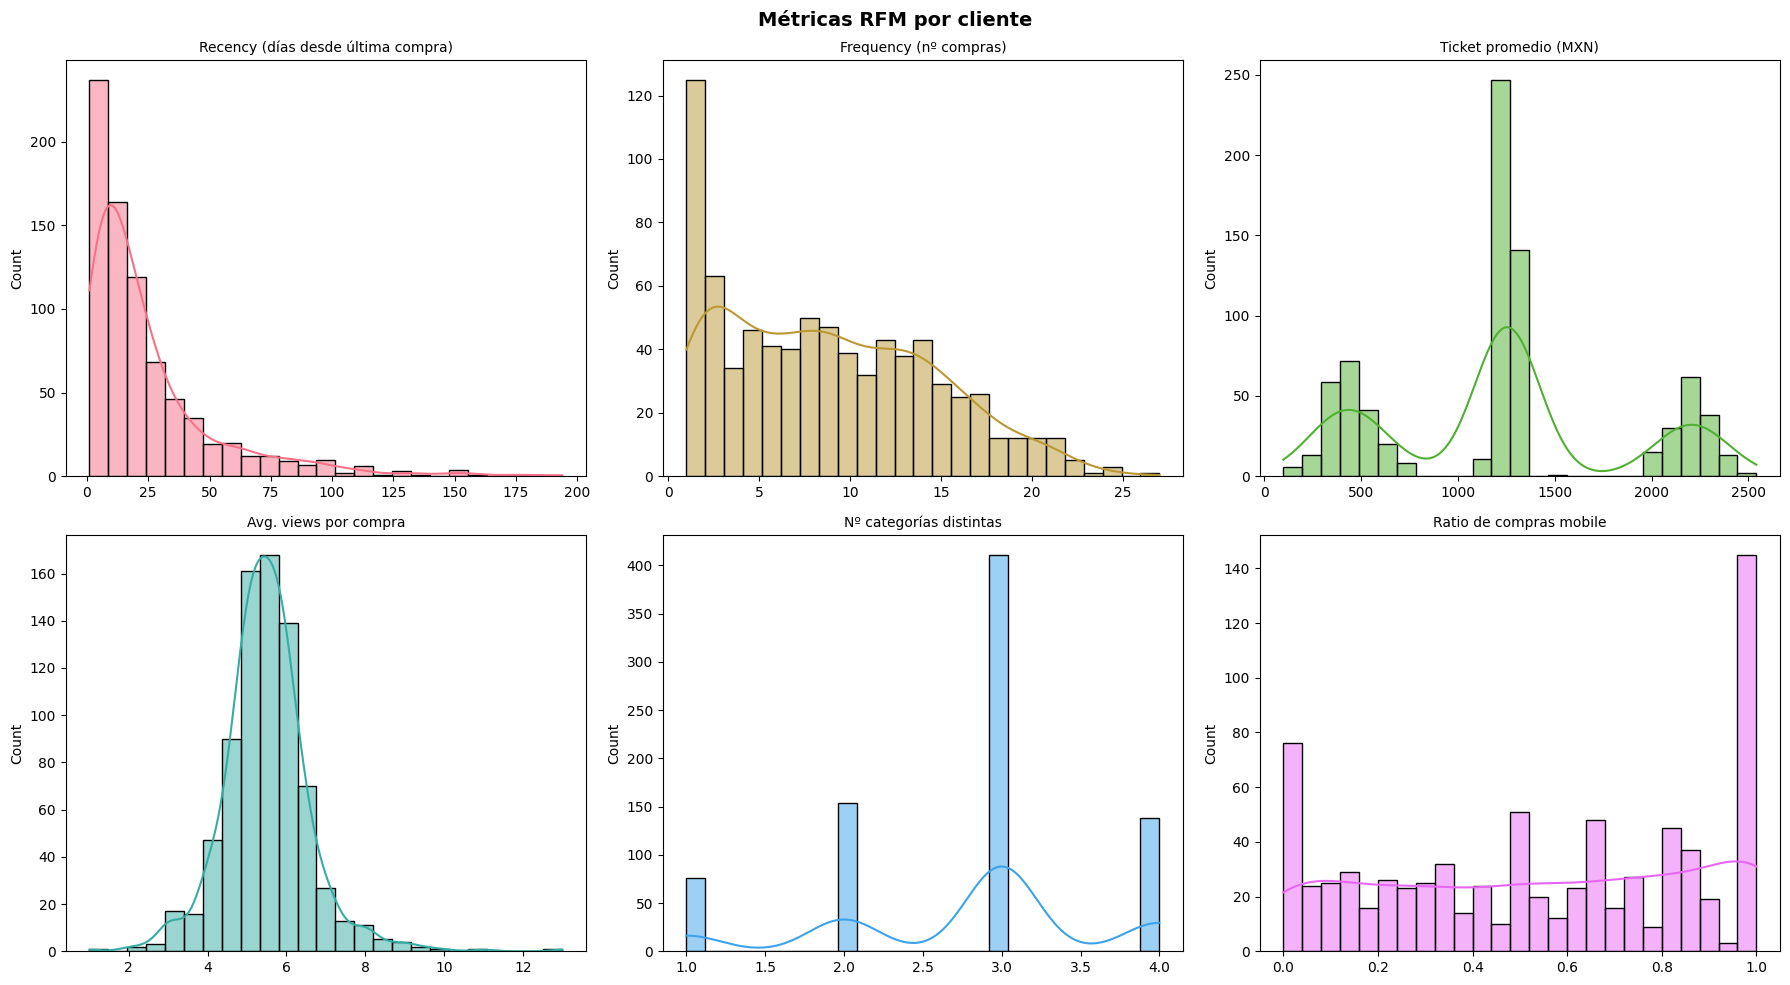

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Habitos de compra de Consumidores", fontsize=14, fontweight="bold")

metrics = [
    ("recency",       "Recency (días desde última compra)"),
    ("frequency",     "Frequency (nº compras)"),
    ("monetary_mean", "Ticket promedio (MXN)"),
    ("avg_views",     "Avg. views por compra"),
    ("categories_cnt","Nº categorías distintas"),
    ("mobile_ratio",  "Ratio de compras mobile"),
]

colors = sns.color_palette(PALETTE, len(metrics))
for ax, (col, title), color in zip(axes.flat, metrics, colors):
    sns.histplot(rfm[col].dropna(), bins=25, kde=True, ax=ax, color=color)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_rfm_cliente.png", dpi=150, bbox_inches="tight")
plt.show()